In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import numpy as np

In [2]:
mod_size = 'small'
TS_opt = 'extrap'
norm_method = 'std'
seed_nb = 1
#np.random.seed(seed_nb)
#tf.random.set_seed(seed_nb)

nemo_run = 'OPM026'
month = '09'

In [3]:
years = (1980,1990,2000,2010,2020)
exp_names = ('NEMO_grid_v0_slope_lat_lon', 'NEMO_grid_v0_slope_front', 'test1', 'test_no_lat')

In [4]:
filepath_AIAI_data = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/'

In [5]:
melt_pred = np.ndarray((len(years), len(exp_names)), dtype = np.ndarray)
melt_ref = np.ndarray((len(years), len(exp_names)), dtype = np.ndarray)
temp_ref = np.ndarray((len(years), len(exp_names)), dtype = np.ndarray) 
for i,j in itertools.product(range(len(years)), range(len(exp_names))):
    #melt_pred[i,j] = i+j
    year = years[i]
    exp_name = exp_names[j]
    filepath_ref = filepath_AIAI_data + 'Testing_data/nn_apply_' + nemo_run + '_' + str(year) + '_' + month + '.csv'
    filepath_pred = filepath_AIAI_data + 'Testing_data/nn_applied_' + nemo_run + '_' + str(year) + '_' + month + '_' + exp_name + '.nc'
    melt_pred[i,j] = xr.open_dataset(filepath_pred)[list(xr.open_dataset(filepath_pred).data_vars)[0]].data 
    reference = pd.read_csv(filepath_ref)
    melt_ref[i,j] = reference.melt_m_ice_per_y
    temp_ref[i,j] = reference.temperature_prop

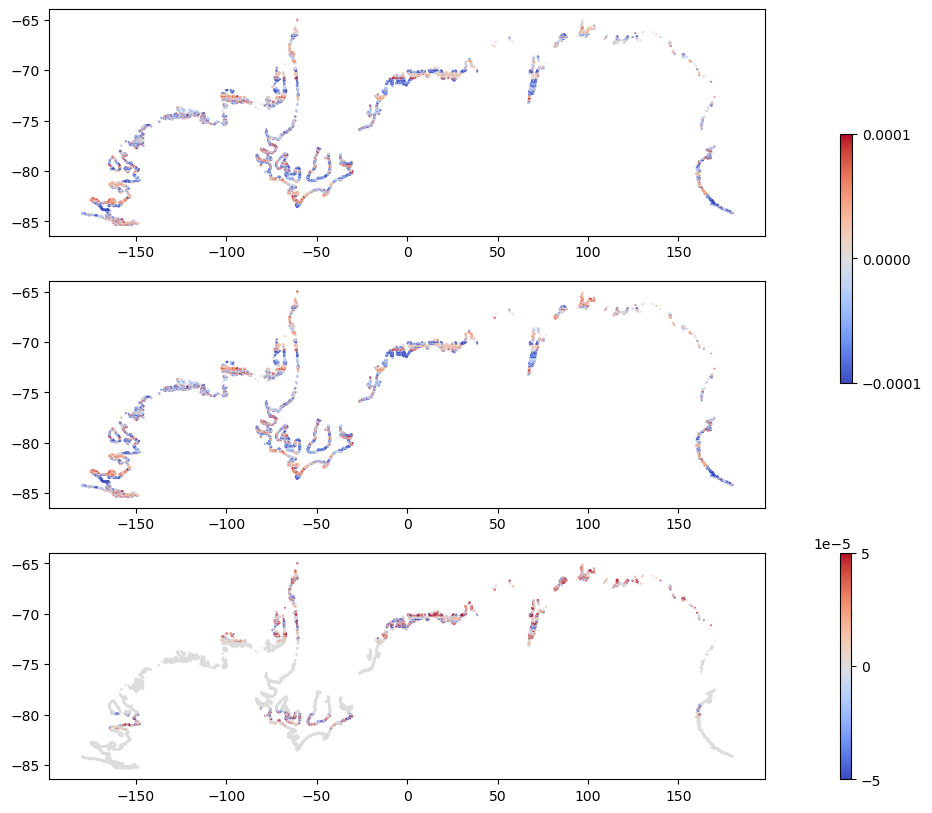

In [18]:
fig, ax = plt.subplots(3,1, figsize = (12,10))
im = [[],[],[]]
im[0] = ax[0].scatter(reference.lon, reference.lat, c = melt_pred[0,1], cmap = 'coolwarm', s = 0.1)
im[1] = ax[1].scatter(reference.lon, reference.lat, c = melt_pred[2,1], cmap = 'coolwarm', s = 0.1)
im[2] = ax[2].scatter(reference.lon, reference.lat, c = melt_pred[2,1]-melt_pred[0,1], cmap = 'coolwarm', s = 0.1)
titles = ['Simulation 1', 'Simulation 2', 'Difference']
#im[1] = ax[1].scatter(clean_df.lon, clean_df.lat, c = y_out, cmap = 'coolwarm')
for i in range(3):
    im[i].set_clim(-0.0001,0.0001)
    #im[1][0].set_clim(
    #ax[i].set_title(titles[i], fontsize =20)
    #ax[i].set_xlim(-65,-50)
    #ax[i].set_ylim(-83.6,-81.1)
im[2].set_clim(-0.00005,0.00005)
cbar = plt.colorbar(im[0], ax = ax[0:2], orientation = 'vertical', shrink = 0.5, pad = 0.08)
cbar.set_ticks((-0.0001,0,0.0001))
cbar2 = plt.colorbar(im[2], ax = ax[2], orientation = 'vertical', shrink = 1, pad = 0.08)
cbar2.set_ticks((-0.00005,0,0.00005))
#ax[0,1].annotate('Variables: {}\nYear:        {}\nMonth:     {}'.format(exp_name, year, month), \
#               xy = (0,-75), xytext = (0.5,0.05), fontsize = 10, textcoords='axes fraction', zorder = 10);

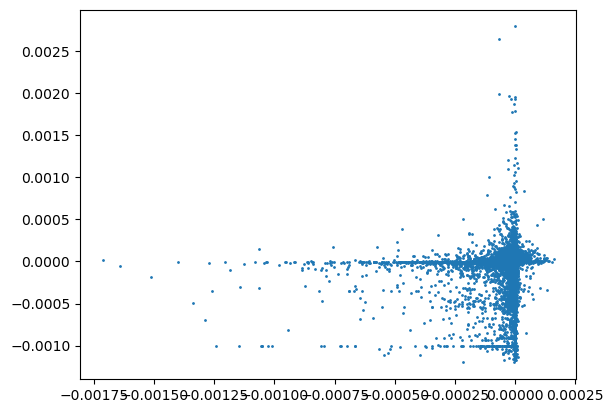

In [34]:
i = 2
j = 3
plt.scatter(melt_ref[i,j], melt_pred[i,j], s = 1)